#Iris Flower Classification · Supervised Machine Learning


## Table of Contents
1. [Introduction & Setup](#1)
2. [Exploratory Data Analysis](#2)
3. [Data Preprocessing](#3)
4. [Train-Test Split](#4)
5. [Model Building](#5)
6. [Model Evaluation](#6)
7. [Model Interpretation](#7)
8. [Trying Other Classifiers](#8)
9. [Making New Predictions](#9)
10. [Conclusion](#10)

##1. Introduction & Setup

###1.1 Project Overview & Objective

The objective of this project is to train the model to learn from the data perovided from kaagle to predict the type of species a flower is based on the features it has.

###1.2 Import Libraries

In [122]:
# The 'AttributeError: 'DataFrame' object has no attribute 'feature_names''
# occurs in cell -Wh9dAKmBK1W because pandas DataFrames do not have this attribute.
# To fix this, in cell -Wh9dAKmBK1W, replace `feature_cols = df.feature_names` with
# the list of your feature column names, for example:
# feature_cols = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
)


###1.3 Load DataSet

In [123]:

file = kagglehub.dataset_download("saurabh00007/iriscsv") +"/Iris.csv"
df = pd.read_csv(file)
df.head()



Using Colab cache for faster access to the 'iriscsv' dataset.


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


##2. Exploratory Data Analysis

###2.1 Data Overview

In [124]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


###2.2  Descriptive Statistics

In [125]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


### 2.3 Class distribution


Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


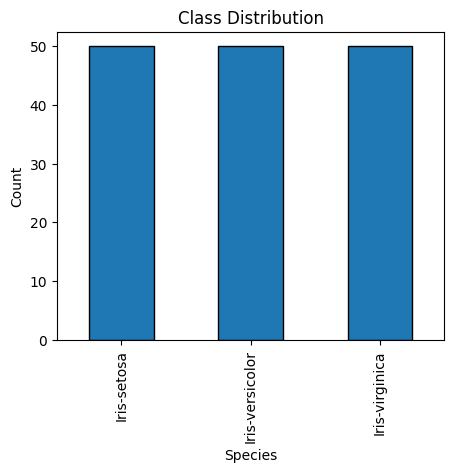

In [126]:
print(df['Species'].value_counts())
plt.figure(figsize =(5,4))
df['Species'].value_counts().plot(kind = 'bar' ,edgecolor = 'black')
plt.xlabel('Species')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.show()

### 2.4 Feature Distributions by Species

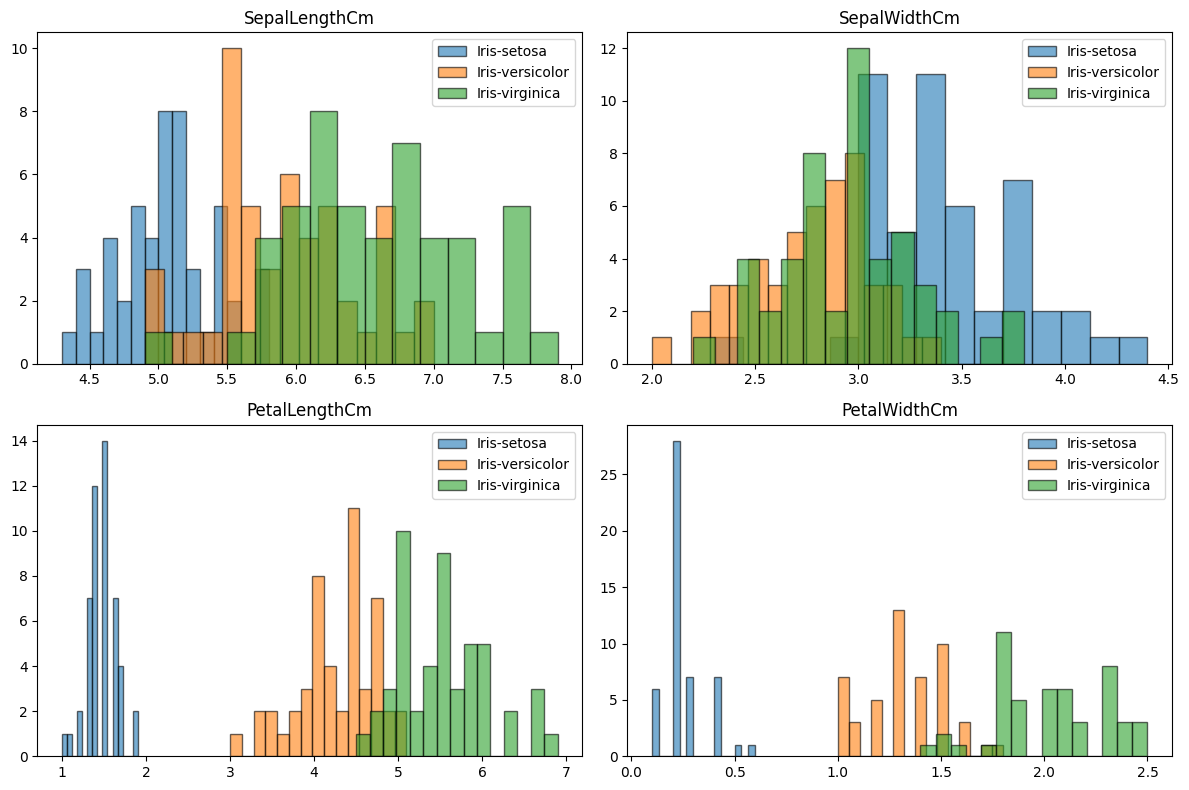

In [127]:
feature_cols = ['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i, col in enumerate(feature_cols):
    for species in df['Species'].unique():
        subset = df[df['Species'] == species]
        axes[i].hist(subset[col], alpha=0.6, label=species, bins=15, edgecolor='black')
    axes[i].set_title(col)
    axes[i].legend()

plt.tight_layout()
plt.show()


### 2.5 Pairwise Relationship(Scatter Matrix)

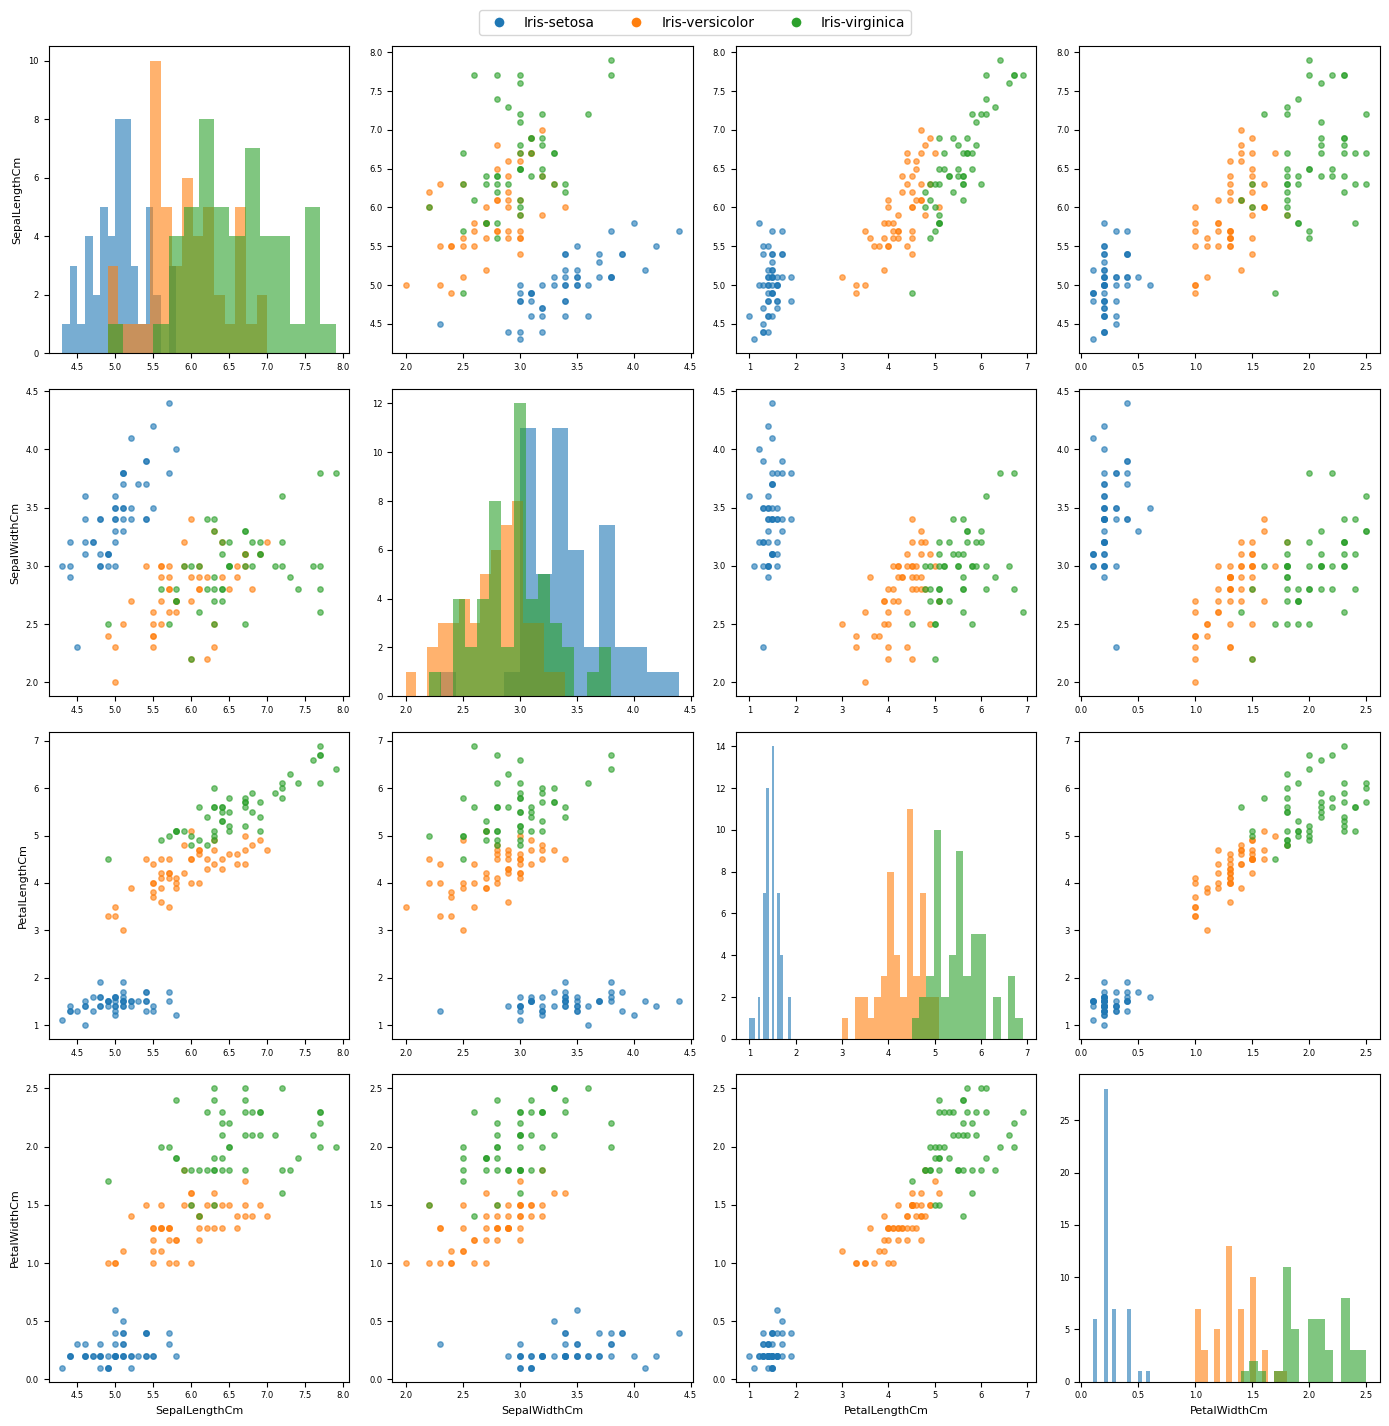

In [128]:
colors = {'Iris-setosa': 'tab:blue', 'Iris-versicolor': 'tab:orange', 'Iris-virginica': 'tab:green'}

fig, axes = plt.subplots(4, 4, figsize=(14, 14))

for i in range(4):
    for j in range(4):
        ax = axes[i, j]
        if i == j:
            for species in df['Species'].unique():
                subset = df[df['Species'] == species]
                ax.hist(subset[feature_cols[i]], alpha=0.6, color=colors[species], bins=15)
        else:
            for species in df['Species'].unique():
                subset = df[df['Species'] == species]
                ax.scatter(subset[feature_cols[j]], subset[feature_cols[i]],
                           alpha=0.6, s=15, color=colors[species], label=species)
        if i == 3:
            ax.set_xlabel(feature_cols[j], fontsize=8)
        if j == 0:
            ax.set_ylabel(feature_cols[i], fontsize=8)
        ax.tick_params(labelsize=6)

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=8, label=s)
           for s, c in colors.items()]
fig.legend(handles=handles, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout()
plt.show()

### 2.6 Correlation Heat Map

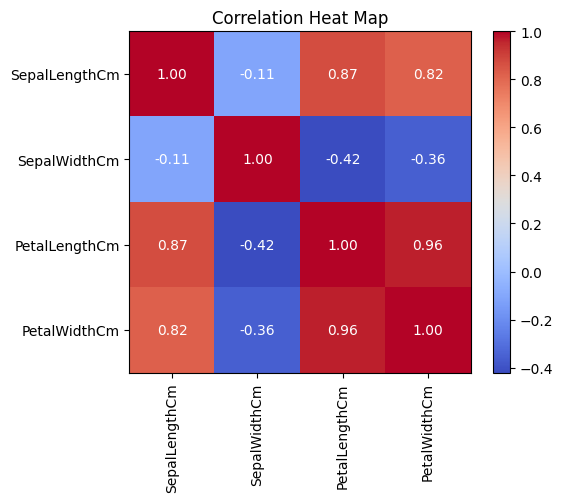

In [129]:
corr  = df[feature_cols].corr()
plt.figure(figsize=(6,5))
plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr.columns)),corr.columns,rotation=90)
plt.yticks(range(len(corr.columns)),corr.columns)
plt.title('Correlation Heat Map')
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', color='white')
plt.tight_layout()
plt.show()

## 2.7 Mising Value Check

In [130]:
print('Missing Value Check')
print(df.isnull().sum())

Missing Value Check
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


##3. Data Processing

###3.1 Seperate features and target

In [131]:
x = df[feature_cols]
y = df['Species']
x.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


#### 3.2 Feature Scaling

In [132]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_scaled = pd.DataFrame(x_scaled, columns = feature_cols)
x_scaled.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,-0.900681,1.032057,-1.341272,-1.312977
1,-1.143017,-0.124958,-1.341272,-1.312977
2,-1.385353,0.337848,-1.398138,-1.312977
3,-1.506521,0.106445,-1.284407,-1.312977
4,-1.021849,1.263460,-1.341272,-1.312977


##4. Train Test Split

In [133]:
x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Training Samples: {x_train.shape[0]}')
print(f'Test Samples: {x_test.shape[0]}')
print('Training Class distribution: ')
print(y_train.value_counts)

Training Samples: 120
Test Samples: 30
Training Class distribution: 
<bound method IndexOpsMixin.value_counts of 8          Iris-setosa
106     Iris-virginica
76     Iris-versicolor
9          Iris-setosa
89     Iris-versicolor
            ...       
37         Iris-setosa
2          Iris-setosa
33         Iris-setosa
52     Iris-versicolor
3          Iris-setosa
Name: Species, Length: 120, dtype: object>


##5. Model Building

###5.1 Train a Classifier (k-Nearest Neighbors)

In [134]:
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(x_train, y_train)
y_pred = knn.predict(x_test)
print(f"Predictionas: {y_pred}")
print(f"Actual Values: {y_test.values}")
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")


Predictionas: ['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa'
 'Iris-virginica' 'Iris-setosa']
Actual Values: ['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa'
 'Ir

## 5.2 Cross-Validation

In [135]:
cv_scores = cross_val_score(knn, x_scaled, y, cv=5)
print("Cross-validation scores:", cv_scores)
print(f"Mean accuracy:, {cv_scores.mean():.4f}(+/- {cv_scores.std():.4f})")


Cross-validation scores: [0.96666667 0.96666667 0.93333333 0.93333333 1.        ]
Mean accuracy:, 0.9600(+/- 0.0249)


##6. Model Evaluation

### 6.1 Accuracy Score

In [136]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.9333


###6.2 Confusion Matrix

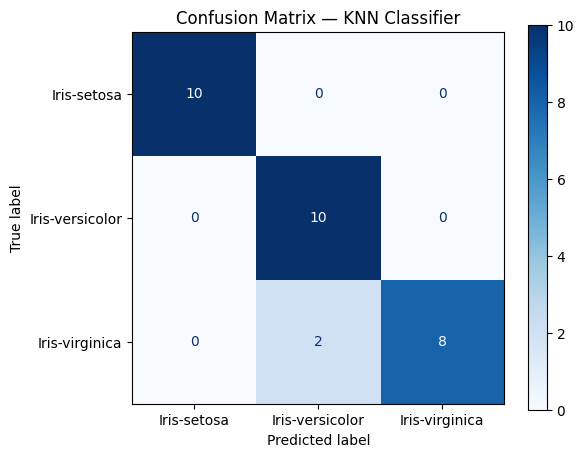

Confusion Matrix:


In [137]:
cm = confusion_matrix(y_test, y_pred,labels =df["Species"].unique())
fig,ax = plt.subplots(figsize = (6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=df['Species'].unique())
disp.plot(ax=ax, cmap='Blues', colorbar=True)
plt.title("Confusion Matrix — KNN Classifier")
plt.show()
print("Confusion Matrix:")


###6.3 Classification Report (Precision,Recall,F1-Score)

In [138]:
print(classification_report(y_test,y_pred,target_names = df['Species'].unique()))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30



##7. Model Interpretation

###7.1 Feature Importance

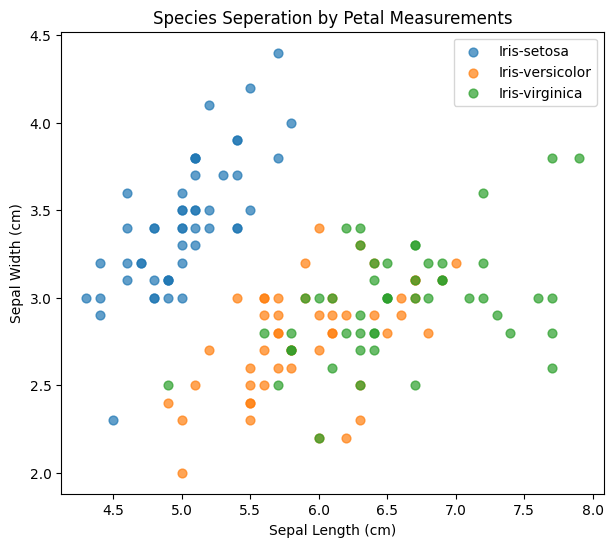

In [139]:
plt.figure(figsize=(7,6))
for species in df["Species"].unique():
  subset = df[df["Species"] ==species]
  plt.scatter(subset["SepalLengthCm"], subset["SepalWidthCm"], label=species, alpha = 0.7, s = 40)
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.title("Species Seperation by Petal Measurements")
plt.legend()
plt.show()

###7.2 Decision tree visualisation (for intuition)

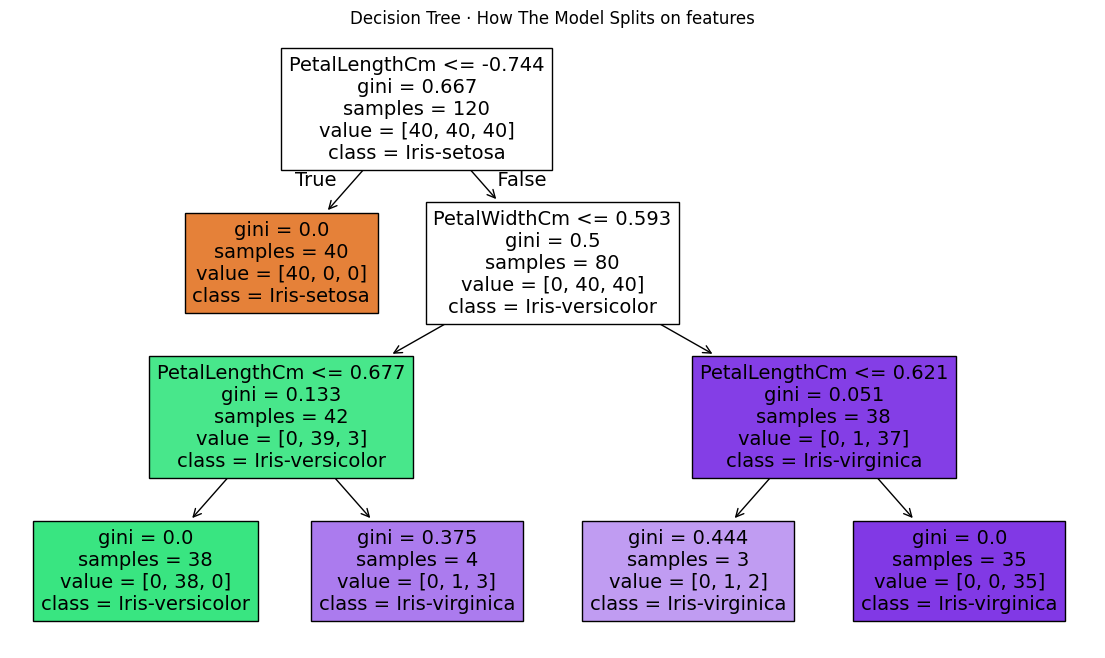

In [140]:
tree_clf = DecisionTreeClassifier(max_depth =3,random_state=42)
tree_clf.fit(x_train, y_train)

plt.figure(figsize=(14,8))
plot_tree(tree_clf, feature_names=feature_cols, class_names=df['Species'].unique(), filled=True)
plt.title("Decision Tree · How The Model Splits on features")
plt.show()

##8. Trying Other Classifiers

In [141]:
models = {
    'KNN': KNeighborsClassifier(),
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC(kernel = 'rbf')
}
results = {}
for name,model in models.items():
  model.fit(x_train, y_train)
  y_pred = model.predict(x_test)
  accuracy = accuracy_score(y_test, y_pred)
  results[name] = accuracy_score(y_test,y_pred)
  #print(f"{name} Accuracy: {accuracy:.4f}")

results_df =pd.DataFrame.from_dict(results, orient = 'index',columns = ['Accuracy'])
results_df = results_df.sort_values('Accuracy', ascending = False)
results_df


,Accuracy
SVM,0.966667
KNN,0.933333
Logistic Regression,0.933333
Decision Tree,0.933333
Random Forest,0.933333


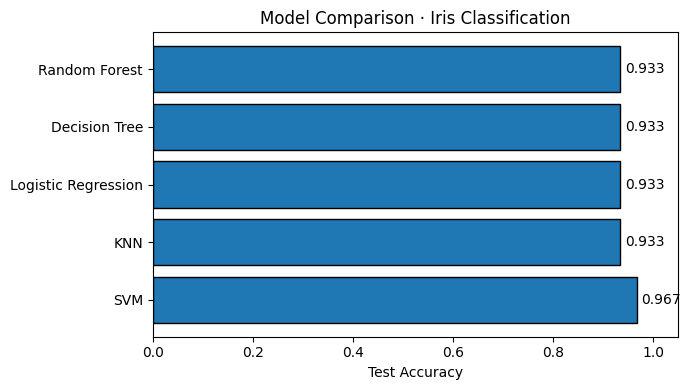

In [142]:
plt.figure(figsize = (7,4))
plt.barh(results_df.index, results_df['Accuracy'],edgecolor = 'black')
plt.xlabel('Test Accuracy')

plt.title('Model Comparison · Iris Classification')
plt.xlim(0,1.05)
for i,v in enumerate(results_df['Accuracy']):
  plt.text(v+ 0.01,i,f'{v:.3f}',va='center')
plt.tight_layout()
plt.show()

##9. Making New Predictions

In [143]:
new_sample = pd.DataFrame([[5.8,2.7,4.1,1.0]],columns = feature_cols)
new_sample_scaled = scaler.transform(new_sample)
prediction = knn.predict(new_sample_scaled)
probabilities= knn.predict_proba(new_sample_scaled)
print(f"Predicted Species: {prediction[0]}")


Predicted Species: Iris-versicolor


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
